# FracAtlas Data Exploration

## Import libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read data

In [4]:
# Đọc file dữ liệu
file_path = r'C:\Users\lebat\Documents\Github\xbone-net\data\FracAtlas\dataset.csv'
df = pd.read_csv(file_path)

print("="*50)
print("1. THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU FRACATLAS")
print("="*50)
print(f"Tổng số ảnh (hàng): {df.shape[0]}")
print(f"Số lượng thuộc tính (cột): {df.shape[1]}")

print("\nThông tin các cột và kiểu dữ liệu:")
print(df.info())

print("\nKiểm tra dữ liệu khuyết thiếu (Missing values):")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "Tuyệt vời, không có dữ liệu bị thiếu!")

# Hiển thị 5 dòng đầu tiên
display(df.head())

1. THÔNG TIN TỔNG QUAN BỘ DỮ LIỆU FRACATLAS
Tổng số ảnh (hàng): 4083
Số lượng thuộc tính (cột): 13

Thông tin các cột và kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 4083 entries, 0 to 4082
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   image_id        4083 non-null   str  
 1   hand            4083 non-null   int64
 2   leg             4083 non-null   int64
 3   hip             4083 non-null   int64
 4   shoulder        4083 non-null   int64
 5   mixed           4083 non-null   int64
 6   hardware        4083 non-null   int64
 7   multiscan       4083 non-null   int64
 8   fractured       4083 non-null   int64
 9   fracture_count  4083 non-null   int64
 10  frontal         4083 non-null   int64
 11  lateral         4083 non-null   int64
 12  oblique         4083 non-null   int64
dtypes: int64(12), str(1)
memory usage: 414.8 KB
None

Kiểm tra dữ liệu khuyết thiếu (Missing values):
Tuyệt vời, không có d

,image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
0,IMG0000000.jpg,0,1,0,0,0,0,1,0,0,1,1,0
1,IMG0000001.jpg,0,1,0,0,0,0,1,0,0,1,1,0
2,IMG0000002.jpg,0,1,0,0,0,0,1,0,0,1,1,0
3,IMG0000003.jpg,0,1,0,0,0,0,1,0,0,0,1,1
4,IMG0000004.jpg,0,1,0,0,0,0,1,0,0,0,1,1


## Fractured sample


2. THỐNG KÊ LỚP GÃY XƯƠNG (FRACTURED)
fractured
Bình thường (0)    3366
Gãy xương (1)       717
Name: count, dtype: int64


C:\Users\lebat\AppData\Local\Temp\ipykernel_40104\410025491.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='fractured', palette=['#2ecc71', '#e74c3c'])


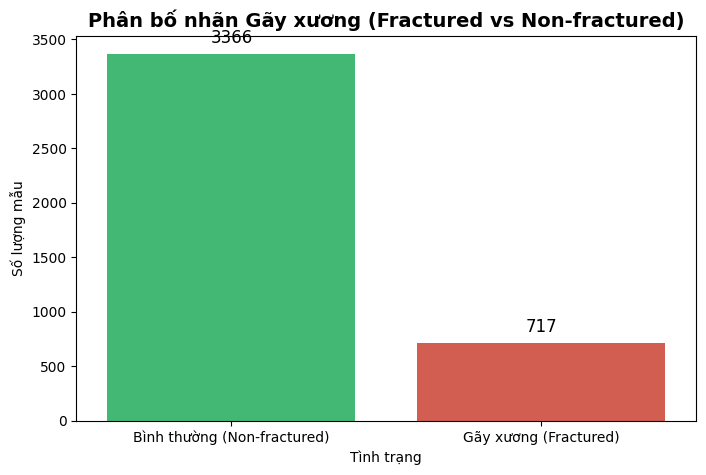


Thống kê số lượng vết gãy trên các ca dương tính (fractured == 1):
fracture_count
1    546
2    146
3     17
4      7
5      1
Name: count, dtype: int64


In [5]:
print("\n" + "="*50)
print("2. THỐNG KÊ LỚP GÃY XƯƠNG (FRACTURED)")
print("="*50)

# Đếm số lượng nhãn
fracture_counts = df['fractured'].value_counts().rename(index={0: 'Bình thường (0)', 1: 'Gãy xương (1)'})
print(fracture_counts)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='fractured', palette=['#2ecc71', '#e74c3c'])
plt.title('Phân bố nhãn Gãy xương (Fractured vs Non-fractured)', fontsize=14, fontweight='bold')
plt.xlabel('Tình trạng')
plt.ylabel('Số lượng mẫu')
plt.xticks(ticks=[0, 1], labels=['Bình thường (Non-fractured)', 'Gãy xương (Fractured)'])

# Hiển thị số lượng cụ thể trên từng cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# Thống kê số lượng vết gãy (fracture_count) trên các ca có gãy
print("\nThống kê số lượng vết gãy trên các ca dương tính (fractured == 1):")
print(df[df['fractured'] == 1]['fracture_count'].value_counts().sort_index())

## Anatomical locations


3. PHÂN BỐ VỊ TRÍ GIẢI PHẪU (ANATOMY)
leg         2273
hand        1538
mixed        398
shoulder     349
hip          338
dtype: int64


C:\Users\lebat\AppData\Local\Temp\ipykernel_40104\1145203255.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=anatomy_counts.index, y=anatomy_counts.values, palette='Blues_r')


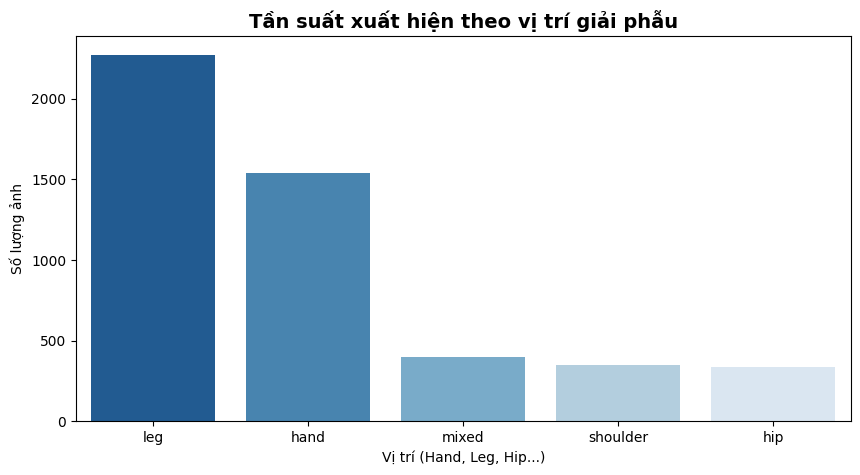

In [6]:
print("\n" + "="*50)
print("3. PHÂN BỐ VỊ TRÍ GIẢI PHẪU (ANATOMY)")
print("="*50)

# Các cột chứa thông tin vị trí giải phẫu
anatomy_cols = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

# Tính tổng số mẫu cho từng vị trí
anatomy_counts = df[anatomy_cols].sum().sort_values(ascending=False)
print(anatomy_counts)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
sns.barplot(x=anatomy_counts.index, y=anatomy_counts.values, palette='Blues_r')
plt.title('Tần suất xuất hiện theo vị trí giải phẫu', fontsize=14, fontweight='bold')
plt.xlabel('Vị trí (Hand, Leg, Hip...)')
plt.ylabel('Số lượng ảnh')
plt.show()

## Others


4. GÓC CHỤP & THUỘC TÍNH PHỤ


C:\Users\lebat\AppData\Local\Temp\ipykernel_40104\110666974.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=view_counts.index, y=view_counts.values, ax=axes[0], palette='magma')
C:\Users\lebat\AppData\Local\Temp\ipykernel_40104\110666974.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=other_counts.index, y=other_counts.values, ax=axes[1], palette='viridis')


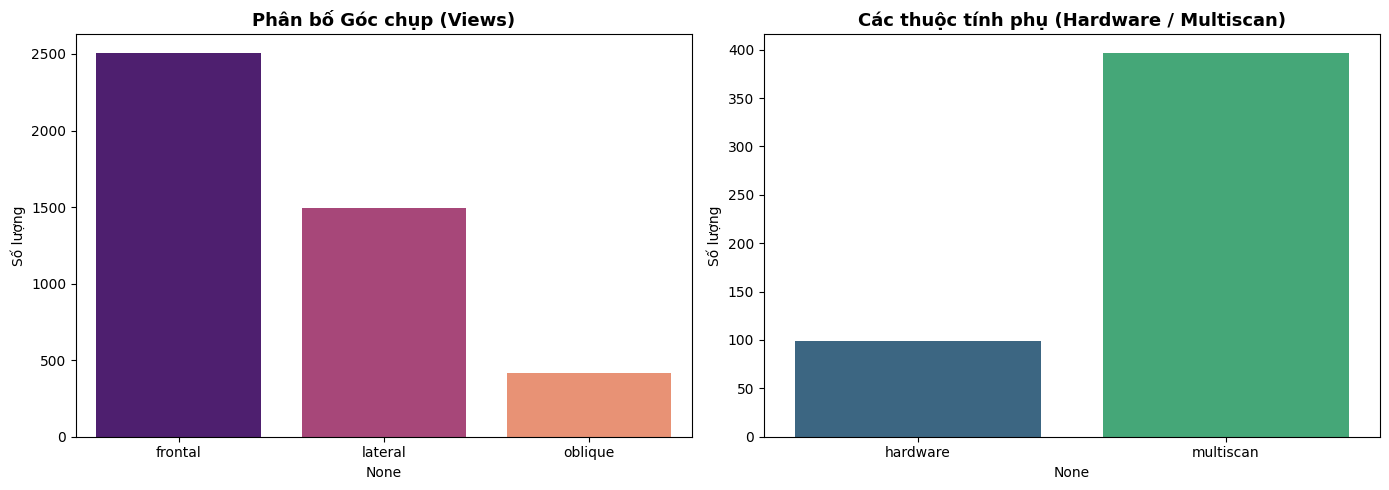

In [7]:
print("\n" + "="*50)
print("4. GÓC CHỤP & THUỘC TÍNH PHỤ")
print("="*50)

# Các cột góc chụp và thuộc tính phụ (phần cứng nẹp vít, quét nhiều lần)
view_cols = ['frontal', 'lateral', 'oblique']
other_cols = ['hardware', 'multiscan']

# Tính tổng
view_counts = df[view_cols].sum()
other_counts = df[other_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ góc chụp
sns.barplot(x=view_counts.index, y=view_counts.values, ax=axes[0], palette='magma')
axes[0].set_title('Phân bố Góc chụp (Views)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng')

# Biểu đồ thuộc tính phụ
sns.barplot(x=other_counts.index, y=other_counts.values, ax=axes[1], palette='viridis')
axes[1].set_title('Các thuộc tính phụ (Hardware / Multiscan)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

## Heatmap


5. TƯƠNG QUAN GIỮA VỊ TRÍ XƯƠNG VÀ TÌNH TRẠNG GÃY


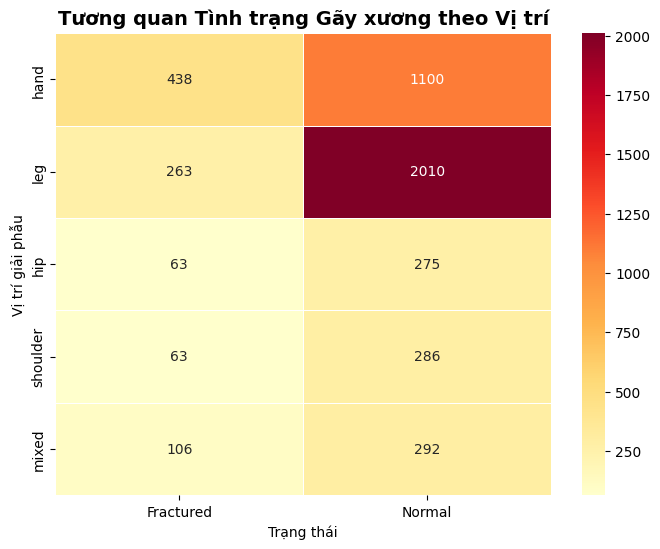


Tỷ lệ gãy xương trên từng vị trí:


,Fracture_Rate (%)
hand,28.48
mixed,26.63
hip,18.64
shoulder,18.05
leg,11.57


In [8]:
print("\n" + "="*50)
print("5. TƯƠNG QUAN GIỮA VỊ TRÍ XƯƠNG VÀ TÌNH TRẠNG GÃY")
print("="*50)

# Tạo ma trận chéo để xem số lượng gãy xương theo từng vị trí
cross_tab = pd.DataFrame()

for anatomy in anatomy_cols:
    # Đếm số ca có vị trí anatomy này VÀ bị gãy (fractured == 1)
    fractured_count = len(df[(df[anatomy] == 1) & (df['fractured'] == 1)])
    # Đếm số ca có vị trí anatomy này VÀ không gãy (fractured == 0)
    normal_count = len(df[(df[anatomy] == 1) & (df['fractured'] == 0)])
    
    cross_tab.loc[anatomy, 'Fractured'] = fractured_count
    cross_tab.loc[anatomy, 'Normal'] = normal_count

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt="g", cmap='YlOrRd', linewidths=.5)
plt.title('Tương quan Tình trạng Gãy xương theo Vị trí', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái')
plt.ylabel('Vị trí giải phẫu')
plt.show()

# Tính tỷ lệ gãy trên từng vị trí
cross_tab['Fracture_Rate (%)'] = round((cross_tab['Fractured'] / (cross_tab['Fractured'] + cross_tab['Normal'])) * 100, 2)
print("\nTỷ lệ gãy xương trên từng vị trí:")
display(cross_tab[['Fracture_Rate (%)']].sort_values(by='Fracture_Rate (%)', ascending=False))